In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import make_dataset as md

# Create the output folder for figures.
# Filenames below match the figures referenced in the thesis LaTeX (figures/).
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Shared figure style: same axis text sizes across every figure, and a
# common per-panel size (PANEL_W x PANEL_H inches) so the axes match.
plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})
PANEL_W, PANEL_H = 4.0, 3.2

df = pd.read_parquet(md.out_path)
if df.empty:
    raise RuntimeError("Dataset is empty.")


# Baseline numerical experiments


## Summary statistics


In [11]:
print("rows, cols:", df.shape)
print(df.describe(include="all").T)
print("\nMissing %:\n", (df.isna().mean().sort_values(ascending=False)*100).round(2))

rows, cols: (950, 9)
                 count        mean         std        min         25%  \
a                950.0    0.343581    0.156220   0.000000    0.230321   
delta_ab         950.0    0.031557    0.018614   0.015633    0.023053   
dim              950.0    1.000000    0.000000   1.000000    1.000000   
sample_id        950.0   24.500000   14.438471   0.000000   12.000000   
num_eigs         950.0  518.058947  319.175186   0.000000  239.500000   
dC1_edges_added  950.0   57.610526    4.480128  46.000000   55.000000   
nz_eig1          900.0    2.575568    2.871426   0.000010    0.289199   
nz_eig2          900.0    3.583954    3.546229   0.000014    0.554965   
nz_eig3          900.0    3.990584    3.688406   0.105796    0.743767   

                        50%         75%          max  
a                  0.361997    0.474216     0.580973  
delta_ab           0.025757    0.031215     0.118730  
dim                1.000000    1.000000     1.000000  
sample_id         24.500000 

**Drop the rows with missing eigenvalues**


In [12]:
df = df.dropna(subset=["nz_eig1","nz_eig2","nz_eig3"])

## Distributions of the covariates and eigenvalues


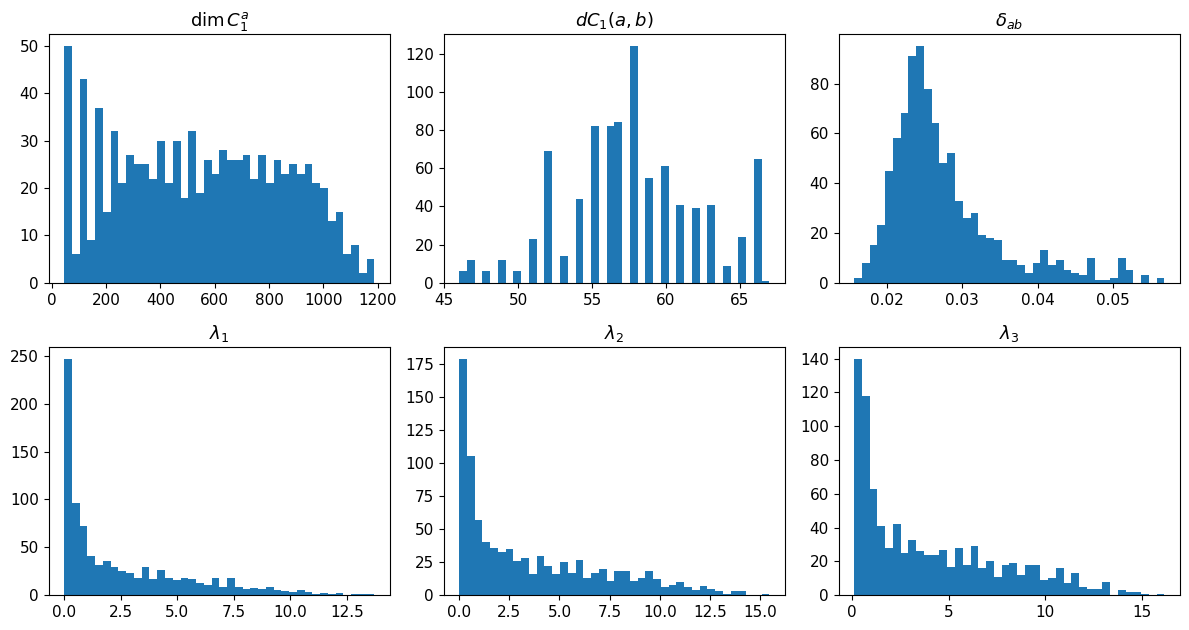

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

cols = ["num_eigs", "dC1_edges_added", "delta_ab", "nz_eig1", "nz_eig2", "nz_eig3"]
label_map = {
    "num_eigs": r"$\dim C_1^a$",
    "dC1_edges_added": r"$dC_1(a,b)$",
    "delta_ab": r"$\delta_{ab}$",
    "nz_eig1": r"$\lambda_1$",
    "nz_eig2": r"$\lambda_2$",
    "nz_eig3": r"$\lambda_3$",
}

fig, ax = plt.subplots(2, 3, figsize=(3 * PANEL_W, 2 * PANEL_H))
for a, c in zip(ax.ravel(), cols):
    a.hist(df[c].dropna(), bins=40)
    a.set_title(label_map[c])

plt.tight_layout()
plt.savefig(FIG_DIR / "distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## The covariates against the filtration parameter $a$


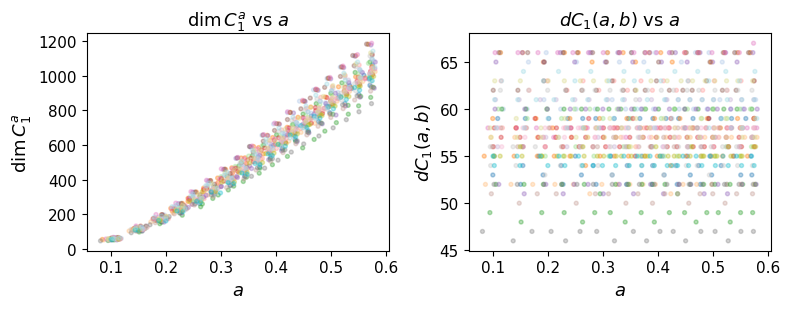

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(2 * PANEL_W, 1 * PANEL_H), sharex=True)

ax[0].scatter(df["a"], df["num_eigs"], c=df["sample_id"], cmap="tab20", s=8, alpha=0.35)
ax[0].set_title(r"$\dim C_1^a$ vs $a$")
ax[0].set_xlabel(r"$a$")
ax[0].set_ylabel(r"$\dim C_1^a$")

ax[1].scatter(df["a"], df["dC1_edges_added"], c=df["sample_id"], cmap="tab20", s=8, alpha=0.35)
ax[1].set_title(r"$dC_1(a,b)$ vs $a$")
ax[1].set_xlabel(r"$a$")
ax[1].set_ylabel(r"$dC_1(a,b)$")

plt.tight_layout()
plt.savefig(FIG_DIR / "dim_vs_a.png", dpi=150, bbox_inches="tight")
plt.show()

## Size and the spectrum


### Over all windows


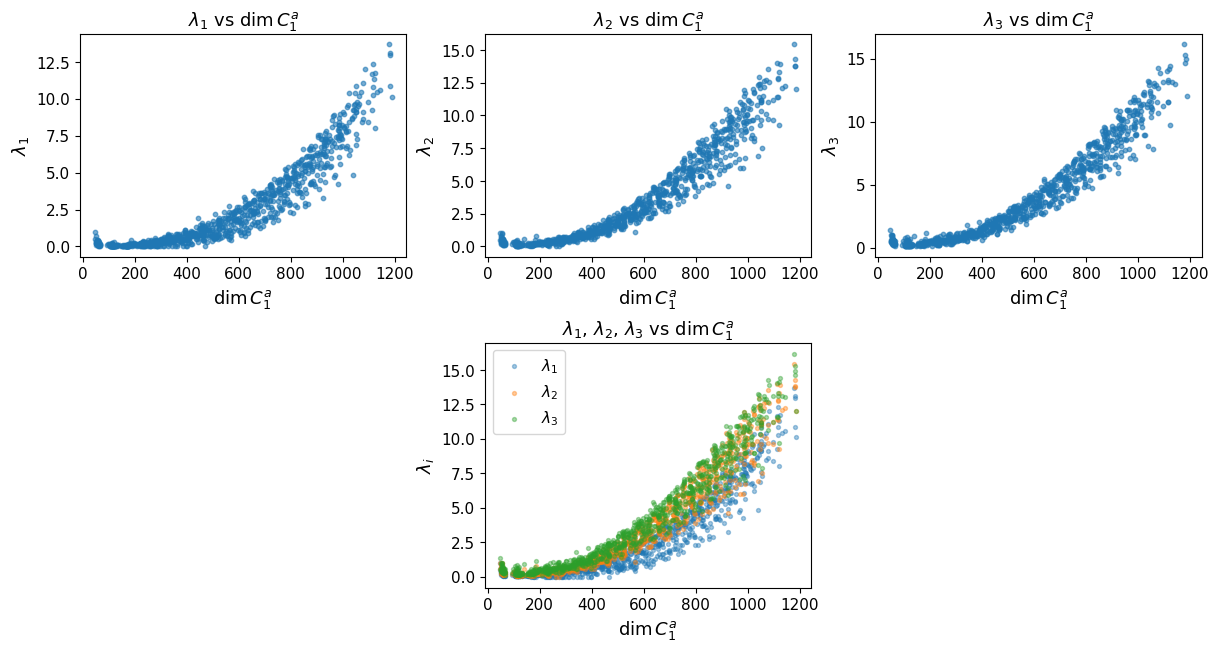

In [15]:
import matplotlib.pyplot as plt
# Data columns
eig_cols = ["nz_eig1", "nz_eig2", "nz_eig3"]
eig_pretty = {"nz_eig1": r"$\lambda_1$", "nz_eig2": r"$\lambda_2$", "nz_eig3": r"$\lambda_3$"}
eig_labels = [eig_pretty[c] for c in eig_cols]


fig = plt.figure(figsize=(3 * PANEL_W, 2 * PANEL_H), constrained_layout=True)
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.1])


axes_top = [fig.add_subplot(gs[0, i]) for i in range(3)]

for ax, eig in zip(axes_top, eig_cols):
    ax.scatter(df["num_eigs"], df[eig], s=10, alpha=0.6)
    ax.set_xlabel(r"$\dim C_1^a$")
    ax.set_ylabel(eig_pretty[eig])
    ax.set_title(rf"{eig_pretty[eig]} vs $\dim C_1^a$")

ax_bottom = fig.add_subplot(gs[1, 1])  

for eig, label in zip(eig_cols, eig_labels):
    ax_bottom.scatter(df["num_eigs"], df[eig], s=8, alpha=0.4, label=label)

ax_bottom.set_xlabel(r"$\dim C_1^a$")
ax_bottom.set_ylabel(r"$\lambda_i$")
ax_bottom.set_title(r"$\lambda_1$, $\lambda_2$, $\lambda_3$ vs $\dim C_1^a$")
ax_bottom.legend()

plt.savefig(FIG_DIR / "scatter_plot.png", dpi=150, bbox_inches="tight")
plt.show()

Maybe:
- exponential
- variance increases
- spread tightens at larger eigenvalues
- I think it is more linear as we move to bigger eigenvalues


It is closer to exponential.

Maybe it is just that the eigenvalue grows because it is a larger eigenvalue, and that adds to the influence of the input-space size $\dim C_1^a$.


### Within individual filtrations


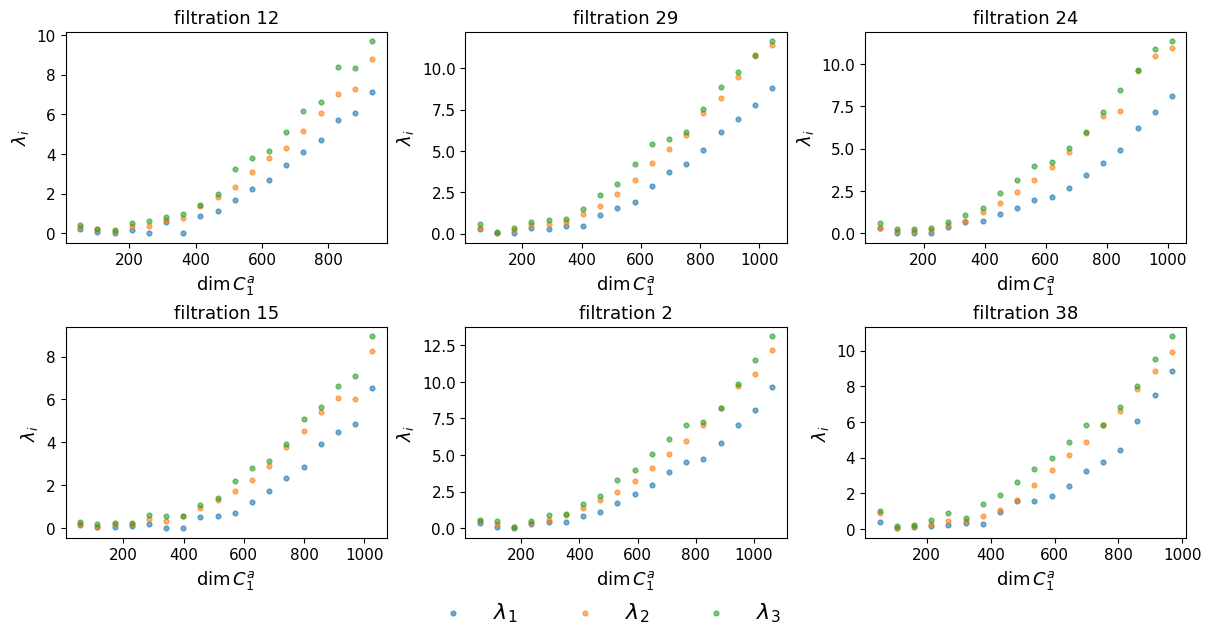

In [23]:
import numpy as np
import matplotlib.pyplot as plt


id_col = "sample_id"  
n_ids = 6
rng = np.random.default_rng(0)  

ids = df[id_col].dropna().unique()
if len(ids) < n_ids:
    raise ValueError(f"Not enough unique ids in '{id_col}': {len(ids)} < {n_ids}")

picked_ids = rng.choice(ids, size=n_ids, replace=False)

xcol = "num_eigs"
eig_cols = ["nz_eig1", "nz_eig2", "nz_eig3"]
eig_pretty = {"nz_eig1": r"$\lambda_1$", "nz_eig2": r"$\lambda_2$", "nz_eig3": r"$\lambda_3$"}


fig, axes = plt.subplots(2, 3, figsize=(3 * PANEL_W, 2 * PANEL_H), constrained_layout=True)
axes = axes.ravel()

for ax, sid in zip(axes, picked_ids):
    d = df[df[id_col] == sid]
    
    for eig in eig_cols:
        ax.scatter(d[xcol], d[eig], s=12, alpha=0.6, label=eig_pretty[eig])

    ax.set_title(f"filtration {sid}")
    ax.set_xlabel(r"$\dim C_1^a$")
    ax.set_ylabel(r"$\lambda_i$")

# show legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=len(eig_cols), frameon=False, fontsize=16)

plt.savefig(FIG_DIR / "scatter_for_10_ids.png", dpi=150, bbox_inches="tight")
plt.show()

## Persistence and the spectrum


### Confounding check


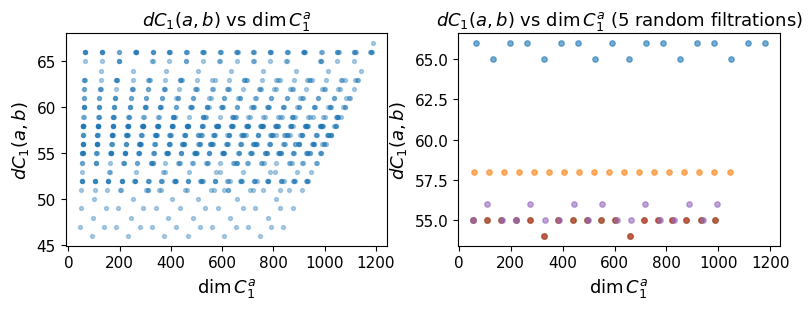

In [17]:
import matplotlib.pyplot as plt
import numpy as np


all_ids = df["sample_id"].unique()
ids = np.random.choice(all_ids, size=5, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(2 * PANEL_W, 1 * PANEL_H))

# Left: all points
axes[0].scatter(df["num_eigs"], df["dC1_edges_added"], s=8, alpha=0.35)
axes[0].set_title(r"$dC_1(a,b)$ vs $\dim C_1^a$")
axes[0].set_xlabel(r"$\dim C_1^a$")
axes[0].set_ylabel(r"$dC_1(a,b)$")

# Right: 5 random ids
cmap = plt.get_cmap("tab10")
for i, id_val in enumerate(ids):
    subset = df[df["sample_id"] == id_val]
    axes[1].scatter(
        subset["num_eigs"],
        subset["dC1_edges_added"],
        s=15,
        alpha=0.6,
        color=cmap(i),
        label=f"filtration {id_val}"
    )

axes[1].set_title(r"$dC_1(a,b)$ vs $\dim C_1^a$ (5 random filtrations)")
axes[1].set_xlabel(r"$\dim C_1^a$")
axes[1].set_ylabel(r"$dC_1(a,b)$")


plt.tight_layout()
plt.savefig(FIG_DIR / "cofund_prev.png", dpi=150, bbox_inches="tight")
plt.show()

### Eigenvalues against the persistence proxy $dC_1(a,b)$


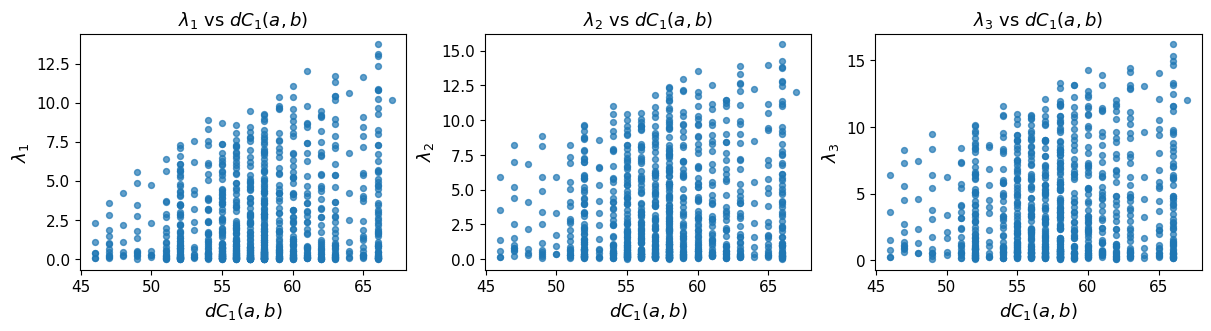

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

proxy_col = "dC1_edges_added"
targets = ["nz_eig1", "nz_eig2", "nz_eig3"]
pretty_names = {
    "nz_eig1": r"$\lambda_1$",
    "nz_eig2": r"$\lambda_2$",
    "nz_eig3": r"$\lambda_3$",
}

# Keep only needed columns
sub = df[[proxy_col] + targets].dropna()

fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL_W, 1 * PANEL_H), constrained_layout=True)

for ax, ycol in zip(axes, targets):
    x = sub[proxy_col].to_numpy()
    y = sub[ycol].to_numpy()

    r = np.corrcoef(x, y)[0, 1]

    ax.scatter(x, y, s=18, alpha=0.7)
    ax.set_xlabel(r"$dC_1(a,b)$")
    ax.set_ylabel(pretty_names[ycol])
    ax.set_title(f"{pretty_names[ycol]} vs $dC_1(a,b)$")




plt.savefig(FIG_DIR / "dC_vs_lamda.png", dpi=150, bbox_inches="tight")
plt.show()


- All the variables except $\delta_{ab}$ are highly correlated with each other.
- The higher the eigenvalue, the more strongly it is determined by the variables.
- The eigenvalues are also highly correlated with each other.
- Since we ran the experiment by increasing the size, this makes sense.


### Eigenvalues against size, coloured by $dC_1(a,b)$

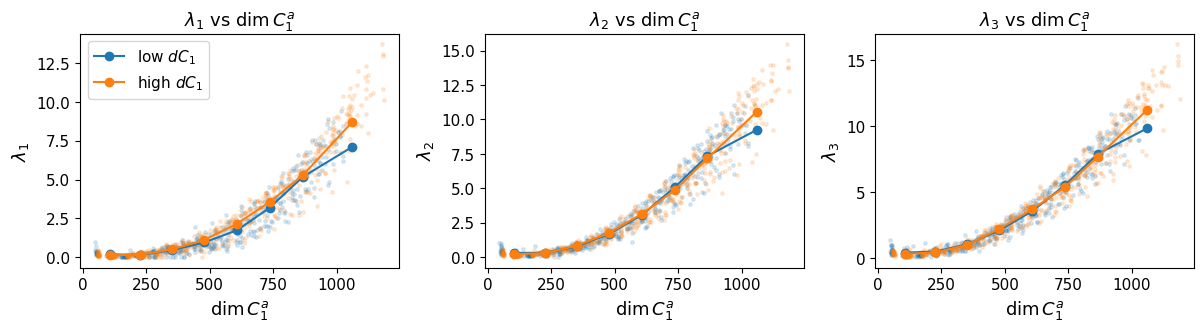

In [22]:
import numpy as np
import matplotlib.pyplot as plt

xcol, ccol = "num_eigs", "dC1_edges_added"
targets = ["nz_eig1", "nz_eig2", "nz_eig3"]
pretty_names = {"nz_eig1": r"$\lambda_1$", "nz_eig2": r"$\lambda_2$", "nz_eig3": r"$\lambda_3$"}

sub = df[[xcol, ccol] + targets].dropna()
x = sub[xcol].to_numpy()
c = sub[ccol].to_numpy()
high = c >= np.median(c)                      # True/False mask: the larger half of the windows by dC_1

# 8 bins of dim C_1^a holding equal point counts (quantile edges, so not equal width)
edges = np.quantile(x, np.linspace(0, 1, 9))
centers = 0.5 * (edges[:-1] + edges[1:])      # midpoint of each bin, used as the x of each line
which = np.clip(np.digitize(x, edges[1:-1]), 0, len(centers) - 1)   # which bin (0..7) each point falls in

fig, axes = plt.subplots(1, 3, figsize=(3 * PANEL_W, 1 * PANEL_H), constrained_layout=True)
for ax, ycol in zip(axes, targets):
    y = sub[ycol].to_numpy()
    # faint cloud behind, split into the same two colours
    ax.scatter(x[~high], y[~high], s=6, alpha=0.15, color="tab:blue")
    ax.scatter(x[high],  y[high],  s=6, alpha=0.15, color="tab:orange")
    for mask, color, lab in [(~high, "tab:blue", "low $dC_1$"),
                             (high, "tab:orange", "high $dC_1$")]:
        # mean lambda inside each source bin, for this dC_1 group
        means = [y[mask & (which == b)].mean() for b in range(len(centers))]
        ax.plot(centers, means, "o-", color=color, label=lab)
    ax.set_xlabel(r"$\dim C_1^a$")
    ax.set_ylabel(pretty_names[ycol])
    ax.set_title(f"{pretty_names[ycol]} vs $\\dim C_1^a$")
axes[0].legend()
plt.savefig(FIG_DIR / "lambda_size_hi_lo_dC.png", dpi=150, bbox_inches="tight")
plt.show()